### LIBRARIES

In [3]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

from sklearn.feature_selection import (
    RFE,
    SelectFromModel,
    SelectKBest,
    f_classif,
    mutual_info_classif,
)

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedGroupKFold, cross_val_predict

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

In [4]:
df_cleaned=pd.read_pickle('data_cleaned.pkl')

In [5]:
#Define the target variable
target_variable = 'flare_next_visit'

#Drop the columns that are not needed for modeling plus the target variable, after EDA analysis.

drop_columns = [
    target_variable,
    'das28_change',
    'comorbidity_count',
    'treatment_count',
    'flare_event',
    'visit_date', 
    'source',
    'year_of_diagnosis',
    'crp_normalized',
    'crp_upper_limit',
    'crp',
    'esr',
    'mtx_use',
    'steroid_use',
    'mtx_dose_category',
    'steroid_dose_category',
    'comorbidities',
    'csdmard_name',
    'b_ts_dmard_name', 
    'switch_reason', 
    'treatment_decision',
    'birth_year',
    'b_ts_dmard_use',
    'visit_type',
    'disease_duration',
    'log_disease_duration',
    'comorb_renal_urological',
    'comorb_respiratory',
    'comorb_autoimmune_other',
    'comorb_gastrointestinal_hepatic',
    'comorb_malignancy',
    'comorb_neurologic_psychiatric',
    'esr_missing',
    'crp_missing',
    'das28_missing',
    'das28_bins_encoded',
    'age_bins_encoded',
    'gender',
    'rf_status',
    'log_esr_lag1',
    'das28_bins',
    'age_bins',
    'esr_lag1',
   
]

#Define the feature matrix X 
X = df_cleaned.drop(columns = drop_columns, errors='ignore')

#Define the target variable y
y = df_cleaned[target_variable]

#Define the groups for group-aware splitting
groups = df_cleaned['patient_id']

In [6]:
X.shape

(393, 17)

In [7]:
X.columns.to_list()

['patient_id',
 'anti_ccp_status',
 'das28_score',
 'mtx_dose',
 'steroid_dose',
 'treatment_decision_grouped',
 'days_since_last_visit',
 'age_at_visit',
 'previous_flare',
 'inflammation_flag',
 'comorb_cardiovascular',
 'comorb_metabolic_endocrine',
 'comorb_musculoskeletal',
 'csdmard_use',
 'log_crp_normalized',
 'log_esr',
 'disease_duration_squared']

In [8]:
continuous_features = [
    'disease_duration_squared',
    'steroid_dose',
    'mtx_dose',
    'age_at_visit',
    'days_since_last_visit',
    
    
]

binary_features = [
    'previous_flare',
    'inflammation_flag',
    'anti_ccp_status',
    'csdmard_use',
    'comorb_cardiovascular',
    'comorb_metabolic_endocrine',
    'comorb_musculoskeletal'
]

categorical_features = [
    'treatment_decision_grouped'
]

In [9]:
stratified_group_kfold = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

In [10]:
#Define preprocessing pipelines with multiple imputation strategies
features = ['das28_score', 'log_esr', 'log_crp_normalized']

#Helper function for das28_change recalculation
def recalculate_das28_change(df):
    df = df.copy()
    das28_col      = [col for col in df.columns if 'das28_score' in col]
    patient_id_col = [col for col in df.columns if 'patient_id' in col]

    if das28_col and patient_id_col:
        das28_col      = das28_col[0]
        patient_id_col = patient_id_col[0]
        df = df.sort_index()
        df['das28_change'] = (
            df.groupby(patient_id_col)[das28_col]
            .diff()
            .fillna(0)
        )
    return df

#Helper function for log_esr_lag1 recalculation
def recalculate_esr_lag1(df):
    df = df.copy()
    esr_col = [col for col in df.columns if 'log_esr' in col]
    patient_id_col = [col for col in df.columns if 'patient_id' in col]

    if esr_col and patient_id_col:
        esr_col = esr_col[0]
        patient_id_col = patient_id_col[0]
        df = df.sort_index()
        df['log_esr_lag1'] = (df.groupby(patient_id_col)[esr_col].shift(1).fillna(0))
    return df


def recalculate_features(df):
    df = recalculate_das28_change(df)
    df = recalculate_esr_lag1(df)
    
    # Drop patient_id after both recalculations are done
    patient_id_col = [col for col in df.columns if 'patient_id' in col]
    if patient_id_col:
        df = df.drop(columns=[patient_id_col[0]])

    return df


def create_preprocessor(disease_metrics_imputer_pipeline):

    preprocessor_parent = ColumnTransformer(transformers=[
        ('cont', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), continuous_features),
        
        ('disease_metrics', disease_metrics_imputer_pipeline, features),
        
        ('bin', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ]), binary_features),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ], remainder='passthrough')
    
    preprocessor_parent.set_output(transform="pandas")
    
    return Pipeline(steps=[
        ('preprocessor_parent', preprocessor_parent),
        ('recalc_features', FunctionTransformer(recalculate_features, validate=False)),
      
       
    ])

# Define imputation strategy pipelines
imputation_strategies = {
    'Median': create_preprocessor(Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        
    ])),
    'KNN': create_preprocessor(Pipeline(steps=[
        ('imputer', KNNImputer(n_neighbors=5)),
        
    ])),
    'MICE_Bayesian': create_preprocessor(Pipeline(steps=[
        ('imputer', IterativeImputer(estimator=BayesianRidge(), random_state=42, max_iter=10)),
        
    ])),
    
    'MICE_RF': create_preprocessor(Pipeline(steps=[
        ('imputer', IterativeImputer(estimator=RandomForestRegressor(n_estimators=50, max_depth = 5, random_state=42, n_jobs=-1), random_state=42, max_iter=15)),
    ]))
}

Imputation strategy : MICE Bayesian

In [12]:
features = ['das28_score', 'log_esr', 'log_crp_normalized']

#Helper function for das28_change recalculation
def recalculate_das28_change(df):
    df = df.copy()
    das28_col      = [col for col in df.columns if 'das28_score' in col]
    patient_id_col = [col for col in df.columns if 'patient_id' in col]

    if das28_col and patient_id_col:
        das28_col      = das28_col[0]
        patient_id_col = patient_id_col[0]
        df = df.sort_index()
        df['das28_change'] = (
            df.groupby(patient_id_col)[das28_col]
            .diff()
            .fillna(0)
        )
    return df

#Helper function for log_esr_lag1 recalculation
def recalculate_esr_lag1(df):
    df = df.copy()
    esr_col = [col for col in df.columns if 'log_esr' in col]
    patient_id_col = [col for col in df.columns if 'patient_id' in col]

    if esr_col and patient_id_col:
        esr_col = esr_col[0]
        patient_id_col = patient_id_col[0]
        df = df.sort_index()
        df['log_esr_lag1'] = (df.groupby(patient_id_col)[esr_col].shift(1).fillna(0))
    return df



def recalculate_features(df):
    df = recalculate_das28_change(df)
    df = recalculate_esr_lag1(df)
    
    # Drop patient_id after both recalculations are done
    patient_id_col = [col for col in df.columns if 'patient_id' in col]
    if patient_id_col:
        df = df.drop(columns=[patient_id_col[0]])

    return df


def create_preprocessor(disease_metrics_imputer_pipeline):

    preprocessor_parent = ColumnTransformer(transformers=[
        ('cont', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), continuous_features),
        
        ('disease_metrics', disease_metrics_imputer_pipeline, features),
        
        ('bin', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ]), binary_features),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ], remainder='passthrough')
    
    preprocessor_parent.set_output(transform="pandas")
    
    return Pipeline(steps=[
        ('preprocessor_parent', preprocessor_parent),
        ('recalc_features', FunctionTransformer(recalculate_features, validate=False)),  
    ])

mice_bayesian_imputation=create_preprocessor(Pipeline(steps=[
        ('imputer', IterativeImputer(estimator=BayesianRidge(), random_state=42, max_iter=10))]))

In [14]:
final_results={}

### Logistic Regression

In [15]:
model_lr = LogisticRegression(
    l1_ratio=0.5,
    solver='saga',
    max_iter=5000,
    random_state=42
)

model_pipeline_lr = Pipeline(steps=[
    ('preprocessor', clone(mice_bayesian_imputation)),
    ('classifier', model_lr)
])

param_grid_lr = {
    'classifier__l1_ratio': [0, 0.15, 0.35, 0.45, 0.5],
    'classifier__C': [0.05, 0.1, 0.5, 1],
    'classifier__class_weight': ['balanced', None],
}

# Nested CV
y_prob_lr = np.zeros(len(y))
best_params_per_fold = []

for fold_idx, (train_idx, test_idx) in enumerate(
        stratified_group_kfold.split(X, y, groups)):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train = groups.iloc[train_idx] 

    # Inner loop
    inner_grid = GridSearchCV(
        estimator=clone(model_pipeline_lr),
        param_grid=param_grid_lr,
        cv=StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42),
        scoring='average_precision',
        n_jobs=-1,
        
        verbose=0
    )
    inner_grid.fit(X_train, y_train, groups=groups_train)

    # Evaluate on outer held-out fold 
    
    # type: ignore
    y_prob_lr[test_idx] = inner_grid.best_estimator_.predict_proba(X_test)[:, 1]
    best_params_per_fold.append({
        'fold': fold_idx + 1,
        'params': inner_grid.best_params_,
        'inner_best_score': inner_grid.best_score_
    })


roc_fpr, roc_tpr, _ = roc_curve(y, y_prob_lr)
roc_auc  = roc_auc_score(y, y_prob_lr)
ap_score = average_precision_score(y, y_prob_lr)

print("Best params per fold:")
for fold in best_params_per_fold:
    print(f"  Fold {fold['fold']}: {fold['params']} | Inner AP: {fold['inner_best_score']:.3f}")

print(f"\nAverage Precision : {ap_score:.4f}")
print(f"ROC AUC           : {roc_auc:.4f}")
print(f"Maximum Probability: {np.max(y_prob_lr):.4f}")
print(f"Minimum Probability: {np.min(y_prob_lr):.4f}")
print(f"Average Probability: {np.mean(y_prob_lr):.4f}\n")

precisions, recalls, thresholds = precision_recall_curve(y, y_prob_lr)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold: {optimal_threshold:.4f}\n")

final_grid_lr = GridSearchCV(
    estimator=clone(model_pipeline_lr),
    param_grid=param_grid_lr,
    cv=stratified_group_kfold,
    scoring='average_precision',
    n_jobs=-1,
   
)
final_grid_lr.fit(X, y, groups=groups)
best_lr = final_grid_lr.best_estimator_

print("Final model best params:", final_grid_lr.best_params_)

#Store results
final_results['Experiment_1_LR'] = {
    'cv_score'  : ap_score,        
    'ap_score'  : ap_score,
    'roc_auc'   : roc_auc,
    'y_true'    : y.copy(),
    'y_prob'    : y_prob_lr,
    'roc_fpr'   : roc_fpr,
    'roc_tpr'   : roc_tpr,
    'precision' : precisions,
    'recall'    : recalls,
    'best_params_per_fold': best_params_per_fold
}

Best params per fold:
  Fold 1: {'classifier__C': 0.05, 'classifier__class_weight': None, 'classifier__l1_ratio': 0.5} | Inner AP: 0.524
  Fold 2: {'classifier__C': 0.05, 'classifier__class_weight': None, 'classifier__l1_ratio': 0.5} | Inner AP: 0.536
  Fold 3: {'classifier__C': 0.05, 'classifier__class_weight': None, 'classifier__l1_ratio': 0.5} | Inner AP: 0.468
  Fold 4: {'classifier__C': 0.05, 'classifier__class_weight': None, 'classifier__l1_ratio': 0.5} | Inner AP: 0.571
  Fold 5: {'classifier__C': 0.05, 'classifier__class_weight': None, 'classifier__l1_ratio': 0.5} | Inner AP: 0.491

Average Precision : 0.5081
ROC AUC           : 0.6949
Maximum Probability: 0.6878
Minimum Probability: 0.1070
Average Probability: 0.3295

Optimal Threshold: 0.2954

Final model best params: {'classifier__C': 0.05, 'classifier__class_weight': 'balanced', 'classifier__l1_ratio': 0.5}


In [17]:
#Get coefficients from the final refitted model
lr_model = best_lr.named_steps['classifier']

# 2. Extract a sample of your transformed feature matrix
X_transformed = mice_bayesian_imputation.fit_transform(X, y)
feature_names = X_transformed.columns 
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': lr_model.coef_[0]}).sort_values('coefficient', key=abs, ascending=False)

#Show only non-zero coefficients
nonzero = coef_df[coef_df['coefficient'] != 0]
print(f"Non-zero coefficients: {len(nonzero)} / {len(coef_df)}")
print(nonzero.to_string())

intercept = lr_model.intercept_[0]
base_prob = 1 / (1 + np.exp(-intercept))
print(f"Model Intercept (Beta_0): {intercept:.6f}")

Non-zero coefficients: 5 / 21
                               feature  coefficient
5         disease_metrics__das28_score     0.511168
6             disease_metrics__log_esr     0.053327
0       cont__disease_duration_squared     0.031545
7  disease_metrics__log_crp_normalized     0.028256
3                   cont__age_at_visit    -0.023253
Model Intercept (Beta_0): -2.015043


In [18]:
y_pred_lr = (y_prob_lr >= 0.2954).astype(int)

# Compute and display metrics
print("\n" + "="*60)
print("LOGISTIC REGRESSION - RESULTS")
print("="*60)
print(classification_report(y, y_pred_lr, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred_lr):.2f}")
print(f"average_precision_score: {average_precision_score(y, y_prob_lr):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob_lr):.2f}")
print("="*60)


LOGISTIC REGRESSION - RESULTS
              precision    recall  f1-score   support

           0       0.85      0.48      0.62       263
           1       0.44      0.83      0.58       130

    accuracy                           0.60       393
   macro avg       0.65      0.66      0.60       393
weighted avg       0.72      0.60      0.60       393

accuracy_score: 0.60
average_precision_score: 0.51
ROC AUC: 0.69


### SVM

In [19]:
model_svm = SVC(
    probability=True,
    random_state=42
)
def mi_classif(X, y):
    return mutual_info_classif(X, y, random_state=42)

model_pipeline_svm = Pipeline(steps=[
    ('preprocessor', clone(mice_bayesian_imputation)),
    ('selector', SelectKBest(score_func=mi_classif)),
    ('classifier', model_svm)
])

param_grid_svm_linear = {
    'selector__k': [5, 7, 10, 'all'],
    'classifier__kernel': ['linear'],
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__class_weight': ['balanced', None],
    'classifier__tol': [1e-4, 1e-3, 1e-2]
}
param_grid_svm_rbf = {
    'selector__k': [5, 7, 10],
    'classifier__kernel': ['rbf'],
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'classifier__class_weight': ['balanced', None],
    'classifier__tol': [1e-4, 1e-3]
}
param_grid_svm_poly = {
    'selector__k': [5, 7, 10],
    'classifier__kernel': ['poly'],
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__degree': [2, 3, 4],
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1],
    'classifier__class_weight': ['balanced', None],
}


#Nested cross validation
y_prob_svm = np.zeros(len(y))
best_params_per_fold = []

outer_cv = stratified_group_kfold


for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups)):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train    = groups.iloc[train_idx]

    inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

    best_inner_score = -np.inf
    best_inner_estimator = None
    best_inner_params = None

    for kernel_grid in [param_grid_svm_linear, param_grid_svm_rbf, param_grid_svm_poly]:
        inner_grid = RandomizedSearchCV(
            estimator=clone(model_pipeline_svm),
            param_distributions=kernel_grid,
            n_iter=50,               
            cv=inner_cv,
            scoring='average_precision',
            n_jobs=-1,
            random_state=42,
            verbose=0,
            error_score=0.0          
        )
        inner_grid.fit(X_train, y_train, groups=groups_train)

        if inner_grid.best_score_ > best_inner_score:
            best_inner_score     = inner_grid.best_score_
            best_inner_estimator = inner_grid.best_estimator_
            best_inner_params    = inner_grid.best_params_

    # Evaluate best estimator from inner loop on outer held-out fold
    y_prob_svm[test_idx] = best_inner_estimator.predict_proba(X_test)[:, 1]
    best_params_per_fold.append({
        'fold': fold_idx + 1,
        'params': best_inner_params,
        'inner_best_score': best_inner_score
    })
    print(f"Fold {fold_idx + 1} | Best kernel: {best_inner_params['classifier__kernel']} "
          f"| Inner AP: {best_inner_score:.3f}")

#Metrics
roc_fpr, roc_tpr, _ = roc_curve(y, y_prob_svm)
roc_auc  = roc_auc_score(y, y_prob_svm)
ap_score = average_precision_score(y, y_prob_svm)

print("\nBest params per fold:")
for fold in best_params_per_fold:
    print(f"  Fold {fold['fold']}: {fold['params']} | Inner AP: {fold['inner_best_score']:.3f}")

print(f"\nAverage Precision : {ap_score:.4f}")
print(f"ROC AUC           : {roc_auc:.4f}")
print(f"Maximum Probability: {np.max(y_prob_svm):.4f}")
print(f"Minimum Probability: {np.min(y_prob_svm):.4f}")
print(f"Average Probability: {np.mean(y_prob_svm):.4f}\n")

precisions, recalls, thresholds = precision_recall_curve(y, y_prob_svm)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold: {optimal_threshold:.4f}\n")

final_grid_svm = RandomizedSearchCV(
    estimator=clone(model_pipeline_svm),
    param_distributions=[param_grid_svm_linear, param_grid_svm_rbf, param_grid_svm_poly],  
    n_iter=50,        
    cv=outer_cv,
    scoring='average_precision',
    n_jobs=-1,
    random_state=42
)
final_grid_svm.fit(X, y, groups=groups)
best_svm = final_grid_svm.best_estimator_ 
print("Final model best params:", final_grid_svm.best_params_)


final_results['Experiment_2_SVM'] = {
    'cv_score'  : ap_score,         
    'ap_score'  : ap_score,
    'roc_auc'   : roc_auc,
    'y_true'    : y.copy(),
    'y_prob'    : y_prob_svm,
    'roc_fpr'   : roc_fpr,
    'roc_tpr'   : roc_tpr,
    'precision' : precisions,
    'recall'    : recalls,
    'best_params_per_fold': best_params_per_fold
}

Fold 1 | Best kernel: poly | Inner AP: 0.511
Fold 2 | Best kernel: rbf | Inner AP: 0.540
Fold 3 | Best kernel: linear | Inner AP: 0.485
Fold 4 | Best kernel: poly | Inner AP: 0.591
Fold 5 | Best kernel: poly | Inner AP: 0.478

Best params per fold:
  Fold 1: {'selector__k': 5, 'classifier__kernel': 'poly', 'classifier__gamma': 0.01, 'classifier__degree': 4, 'classifier__class_weight': 'balanced', 'classifier__C': 0.01} | Inner AP: 0.511
  Fold 2: {'selector__k': 5, 'classifier__tol': 0.0001, 'classifier__kernel': 'rbf', 'classifier__gamma': 0.1, 'classifier__class_weight': 'balanced', 'classifier__C': 0.1} | Inner AP: 0.540
  Fold 3: {'selector__k': 'all', 'classifier__tol': 0.001, 'classifier__kernel': 'linear', 'classifier__class_weight': 'balanced', 'classifier__C': 0.1} | Inner AP: 0.485
  Fold 4: {'selector__k': 5, 'classifier__kernel': 'poly', 'classifier__gamma': 0.01, 'classifier__degree': 4, 'classifier__class_weight': 'balanced', 'classifier__C': 0.01} | Inner AP: 0.591
  Fol

In [20]:
y_pred_svm = (y_prob_svm >= 0.2876).astype(int) 

print("\n" + "="*60)
print("SVM - RESULTS")
print("="*60)
print(classification_report(y, y_pred_svm, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred_svm):.2f}")
print(f"average_precision_score: {average_precision_score(y, y_prob_svm):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob_svm):.2f}")
print("="*60)


SVM - RESULTS
              precision    recall  f1-score   support

           0       0.88      0.30      0.45       263
           1       0.39      0.92      0.55       130

    accuracy                           0.51       393
   macro avg       0.64      0.61      0.50       393
weighted avg       0.72      0.51      0.48       393

accuracy_score: 0.51
average_precision_score: 0.47
ROC AUC: 0.64


### Random Forest

In [21]:
model_rf = RandomForestClassifier(
    n_jobs=1, 
    random_state=42
)

model_pipeline_rf = Pipeline(steps=[
    ('preprocessor', clone(mice_bayesian_imputation)),
    ('classifier', model_rf)
])

param_grid_rf = {
    'classifier__n_estimators': [100, 300, 500],
    'classifier__max_depth': [3, 4, 5],
    'classifier__min_samples_leaf': [3, 5, 7, 10],
    'classifier__min_samples_split': [10, 15, 20],
    'classifier__min_impurity_decrease': [0.0, 0.001, 0.005, 0.01],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}

# Nested cross validation
y_prob_rf = np.zeros(len(y))
best_params_per_fold = []

outer_cv = stratified_group_kfold
inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups)):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train    = groups.iloc[train_idx]  

    inner_grid = RandomizedSearchCV(
        estimator=clone(model_pipeline_rf),
        param_distributions=param_grid_rf,
        n_iter=50,
        cv=inner_cv,
        scoring='average_precision',
        n_jobs=-1,
        random_state=42,
        verbose=0,
        error_score=0.0
    )
    inner_grid.fit(X_train, y_train, groups=groups_train)

    y_prob_rf[test_idx] = inner_grid.best_estimator_.predict_proba(X_test)[:, 1]
    best_params_per_fold.append({
        'fold': fold_idx + 1,
        'params': inner_grid.best_params_,
        'inner_best_score': inner_grid.best_score_
    })
    print(f"Fold {fold_idx + 1} | Inner AP: {inner_grid.best_score_:.3f} "
          f"| Params: {inner_grid.best_params_}")

roc_fpr, roc_tpr, _ = roc_curve(y, y_prob_rf)
roc_auc  = roc_auc_score(y, y_prob_rf)
ap_score = average_precision_score(y, y_prob_rf)

print("\nBest params per fold:")
for fold in best_params_per_fold:
    print(f"  Fold {fold['fold']}: {fold['params']} | Inner AP: {fold['inner_best_score']:.3f}")

print(f"\nAverage Precision : {ap_score:.4f}")
print(f"ROC AUC           : {roc_auc:.4f}")
print(f"Maximum Probability: {np.max(y_prob_rf):.4f}")
print(f"Minimum Probability: {np.min(y_prob_rf):.4f}")
print(f"Average Probability: {np.mean(y_prob_rf):.4f}\n")

precisions, recalls, thresholds = precision_recall_curve(y, y_prob_rf)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold: {optimal_threshold:.4f}\n")


final_grid_rf =RandomizedSearchCV(
    estimator=clone(model_pipeline_rf),
    param_distributions=param_grid_rf,
    n_iter=50,
    cv=outer_cv,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)
final_grid_rf.fit(X, y, groups=groups)
best_rf = final_grid_rf.best_estimator_ 
print("Final model best params:", final_grid_rf.best_params_)

final_results['Experiment_3_RF'] = {
    'cv_score'  : ap_score,         
    'ap_score'  : ap_score,
    'roc_auc'   : roc_auc,
    'y_true'    : y.copy(),
    'y_prob'    : y_prob_rf,
    'roc_fpr'   : roc_fpr,
    'roc_tpr'   : roc_tpr,
    'precision' : precisions,
    'recall'    : recalls,
    'best_params_per_fold': best_params_per_fold
}

Fold 1 | Inner AP: 0.420 | Params: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 20, 'classifier__min_samples_leaf': 10, 'classifier__min_impurity_decrease': 0.001, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 3, 'classifier__criterion': 'gini', 'classifier__class_weight': 'balanced'}
Fold 2 | Inner AP: 0.497 | Params: {'classifier__n_estimators': 500, 'classifier__min_samples_split': 15, 'classifier__min_samples_leaf': 10, 'classifier__min_impurity_decrease': 0.0, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 3, 'classifier__criterion': 'gini', 'classifier__class_weight': 'balanced'}
Fold 3 | Inner AP: 0.438 | Params: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 15, 'classifier__min_samples_leaf': 10, 'classifier__min_impurity_decrease': 0.01, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 3, 'classifier__criterion': 'gini', 'classifier__class_weight': 'balanced_subsample'}
Fold 4 | Inner AP: 0.481

In [22]:
y_pred_rf = (y_prob_rf >= 0.3758).astype(int)

print("\n" + "="*60)
print("RANDOM FOREST - RF RESULTS")
print("="*60)
print(classification_report(y, y_pred_rf, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred_rf):.2f}")
print(f"average_precision_score: {average_precision_score(y, y_prob_rf):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob_rf):.2f}")
print("="*60)


RANDOM FOREST - RF RESULTS
              precision    recall  f1-score   support

           0       0.87      0.38      0.53       263
           1       0.41      0.88      0.56       130

    accuracy                           0.54       393
   macro avg       0.64      0.63      0.54       393
weighted avg       0.72      0.54      0.54       393

accuracy_score: 0.54
average_precision_score: 0.41
ROC AUC: 0.65


### XGBoost

In [23]:
model_xgb = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    n_jobs=1,
    tree_method='hist',  
)

model_pipeline_xgb = Pipeline(steps=[
    ('preprocessor', clone(mice_bayesian_imputation)),
    ('classifier', model_xgb)
])

param_grid_xgb = {
    'classifier__n_estimators': [200, 300, 500],
    'classifier__learning_rate': [0.005, 0.01, 0.05],
    'classifier__max_depth': [2, 3],
    'classifier__min_child_weight': [6, 10],
    'classifier__subsample': [0.6, 0.7, 0.8],
    'classifier__colsample_bytree': [0.5, 0.6, 0.8],
    'classifier__gamma': [0.1, 0.3, 0.5],       
    'classifier__reg_alpha': [0, 0.1, 0.5, 1.0],    
    'classifier__reg_lambda': [3, 5],            
}

#Nested cross validation
y_prob_xgb = np.zeros(len(y))
best_params_per_fold = []

inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups)):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train    = groups.iloc[train_idx]

    # Compute scale_pos_weight from this fold's training labels only
    neg_train, pos_train = (y_train == 0).sum(), (y_train == 1).sum()
    fold_ratio = neg_train / pos_train

    # Add fold-specific scale_pos_weight variants to the grid
    fold_param_grid = {
        **param_grid_xgb,
        'classifier__scale_pos_weight': [fold_ratio * 0.75, fold_ratio, fold_ratio * 1.25]
    }

    inner_grid = RandomizedSearchCV(
        estimator=clone(model_pipeline_xgb),
        param_distributions=fold_param_grid,
        n_iter=60,
        cv=inner_cv,
        scoring='average_precision',
        n_jobs=-1,
        random_state=42,
        verbose=0,
        error_score=0.0
    )
    inner_grid.fit(X_train, y_train, groups=groups_train)

    y_prob_xgb[test_idx] = inner_grid.best_estimator_.predict_proba(X_test)[:, 1]
    best_params_per_fold.append({
        'fold': fold_idx + 1,
        'params': inner_grid.best_params_,
        'inner_best_score': inner_grid.best_score_,
        'fold_ratio': fold_ratio
    })
    print(f"Fold {fold_idx + 1} | Inner AP: {inner_grid.best_score_:.3f} "
          f"| depth={inner_grid.best_params_['classifier__max_depth']} "
          f"| gamma={inner_grid.best_params_['classifier__gamma']} "
          f"| alpha={inner_grid.best_params_['classifier__reg_alpha']} "
          f"| lambda={inner_grid.best_params_['classifier__reg_lambda']}")

roc_fpr, roc_tpr, _ = roc_curve(y, y_prob_xgb)
roc_auc  = roc_auc_score(y, y_prob_xgb)
ap_score = average_precision_score(y, y_prob_xgb)

print("\nBest params per fold:")
for fold in best_params_per_fold:
    print(f"  Fold {fold['fold']}: {fold['params']} "
          f"| Inner AP: {fold['inner_best_score']:.3f} "
          f"| Fold ratio: {fold['fold_ratio']:.3f}")

print(f"\nAverage Precision : {ap_score:.4f}")
print(f"ROC AUC           : {roc_auc:.4f}")
print(f"Maximum Probability: {np.max(y_prob_xgb):.4f}")
print(f"Minimum Probability: {np.min(y_prob_xgb):.4f}")
print(f"Average Probability: {np.mean(y_prob_xgb):.4f}\n")

precisions, recalls, thresholds = precision_recall_curve(y, y_prob_xgb)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold: {optimal_threshold:.4f}\n")

neg_full, pos_full = (y == 0).sum(), (y == 1).sum()
ratio_full = neg_full / pos_full

final_grid_xgb = RandomizedSearchCV(
    estimator=clone(model_pipeline_xgb),
    param_distributions=param_grid_xgb,
    n_iter=60,
    cv=stratified_group_kfold,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)
final_grid_xgb.fit(X, y, groups=groups)
best_xgb = final_grid_xgb.best_estimator_  
print("Final model best params:", final_grid_xgb.best_params_)

#Results
final_results['Experiment_4_XGB'] = {
    'cv_score'  : ap_score,        
    'ap_score'  : ap_score,
    'roc_auc'   : roc_auc,
    'y_true'    : y.copy(),
    'y_prob'    : y_prob_xgb,
    'roc_fpr'   : roc_fpr,
    'roc_tpr'   : roc_tpr,
    'precision' : precisions,
    'recall'    : recalls,
    'best_params_per_fold': best_params_per_fold
}

Fold 1 | Inner AP: 0.471 | depth=2 | gamma=0.5 | alpha=1.0 | lambda=3
Fold 2 | Inner AP: 0.501 | depth=3 | gamma=0.1 | alpha=0 | lambda=5
Fold 3 | Inner AP: 0.440 | depth=2 | gamma=0.1 | alpha=0.5 | lambda=5
Fold 4 | Inner AP: 0.514 | depth=2 | gamma=0.1 | alpha=0.1 | lambda=5
Fold 5 | Inner AP: 0.437 | depth=2 | gamma=0.1 | alpha=0.1 | lambda=5

Best params per fold:
  Fold 1: {'classifier__subsample': 0.6, 'classifier__scale_pos_weight': np.float64(1.5216346153846154), 'classifier__reg_lambda': 3, 'classifier__reg_alpha': 1.0, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 10, 'classifier__max_depth': 2, 'classifier__learning_rate': 0.01, 'classifier__gamma': 0.5, 'classifier__colsample_bytree': 0.8} | Inner AP: 0.471 | Fold ratio: 2.029
  Fold 2: {'classifier__subsample': 0.6, 'classifier__scale_pos_weight': np.float64(1.5216346153846154), 'classifier__reg_lambda': 5, 'classifier__reg_alpha': 0, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 10, '

In [24]:
y_pred_xgb = (y_prob_xgb >= 0.3416).astype(int)

print("\n" + "="*60)
print("XGBOOST - RESULTS")
print("="*60)
print(classification_report(y, y_pred_xgb, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred_xgb):.2f}")
print(f"average_precision_score: {average_precision_score(y, y_prob_xgb):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob_xgb):.2f}")
print("="*60)


XGBOOST - RESULTS
              precision    recall  f1-score   support

           0       0.87      0.40      0.54       263
           1       0.42      0.88      0.57       130

    accuracy                           0.56       393
   macro avg       0.65      0.64      0.56       393
weighted avg       0.72      0.56      0.55       393

accuracy_score: 0.56
average_precision_score: 0.45
ROC AUC: 0.67


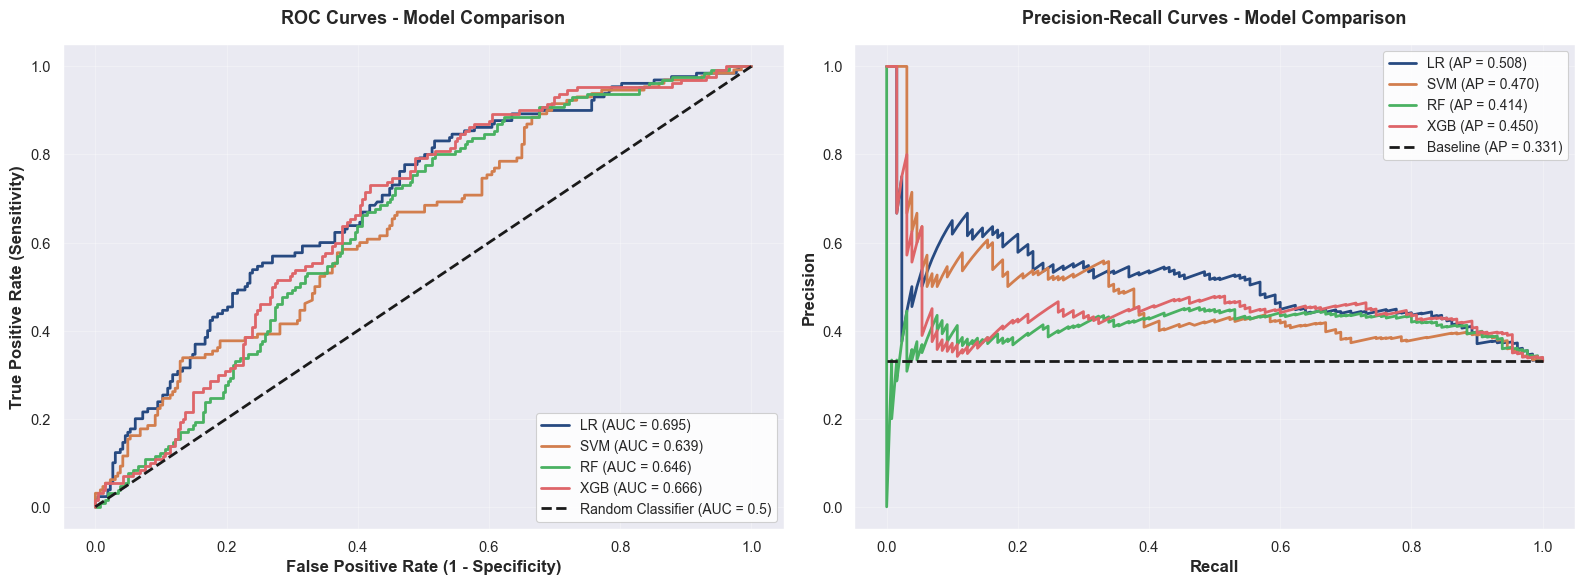

In [25]:
models_to_plot = [
    'Experiment_1_LR', 
    'Experiment_2_SVM',
    'Experiment_3_RF',
    'Experiment_4_XGB',
    
]

model_display_names = ['LR', 'SVM', 'RF', 'XGB']
colors = ["#274a81", "#d27e4e", "#4ab162", "#de6569"]

sns.set_theme(style='darkgrid', context='paper', font_scale=1.2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

first_model_data = models_to_plot[0]
pr_baseline = np.sum(final_results[first_model_data]['y_true']) / len(final_results[first_model_data]['y_true'])

for i, (model_name, display_name, color) in enumerate(zip(models_to_plot, model_display_names, colors)):
    metrics = final_results[model_name]

    # ROC curve
    ax1.plot(
        metrics['roc_fpr'], 
        metrics['roc_tpr'], 
        linewidth=2,
        color=color,
        label=f"{display_name} (AUC = {metrics['roc_auc']:.3f})"
    )
    
    # PR curve
    ax2.plot(
        metrics['recall'],
        metrics['precision'],
        linewidth=2,
        color=color,
        label=f"{display_name} (AP = {metrics['ap_score']:.3f})"
    )

ax1.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5)')
ax1.set_xlim([-0.05, 1.05])
ax1.set_ylim([-0.05, 1.05])
ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontweight='bold', fontsize=12)
ax1.set_ylabel('True Positive Rate (Sensitivity)', fontweight='bold', fontsize=12)
ax1.set_title('ROC Curves - Model Comparison', fontweight='bold', fontsize=13, pad=15)
ax1.legend(loc='lower right', fontsize=10, framealpha=0.9, facecolor='white')
ax1.grid(True, alpha=0.3)

ax2.hlines(pr_baseline, 0, 1, colors='k', linestyles='--', linewidth=2, label=f'Baseline (AP = {pr_baseline:.3f})')
ax2.set_xlim([-0.05, 1.05])
ax2.set_ylim([-0.05, 1.05])
ax2.set_xlabel('Recall', fontweight='bold', fontsize=12)
ax2.set_ylabel('Precision', fontweight='bold', fontsize=12)
ax2.set_title('Precision-Recall Curves - Model Comparison', fontweight='bold', fontsize=13, pad=15)
ax2.legend(loc='best', fontsize=10, framealpha=0.9, facecolor='white')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
def calculate_confidence_intervals(y_true, y_prob, n_bootstraps=1000, random_state=42):

    y_true_arr, y_prob_arr = np.array(y_true), np.array(y_prob)
    rng = np.random.RandomState(random_state)
    roc_aucs, pr_aucs = [], []
    
    #Perform bootstrap resampling with replacement
    for _ in range(n_bootstraps):
        idx = rng.randint(0, len(y_prob_arr), len(y_prob_arr))
        #Skip if bootstrap sample doesn't have both positive and negative classes
        if len(np.unique(y_true_arr[idx])) < 2:
            continue
        #Compute metrics for this bootstrap sample
        roc_aucs.append(roc_auc_score(y_true_arr[idx], y_prob_arr[idx]))
        pr_aucs.append(average_precision_score(y_true_arr[idx], y_prob_arr[idx]))
    
    #Return 95% CI (2.5th to 97.5th percentiles)
    return (np.percentile(roc_aucs, 2.5), np.percentile(roc_aucs, 97.5)), \
           (np.percentile(pr_aucs, 2.5), np.percentile(pr_aucs, 97.5))

#Calculate confidence intervals for each model
ci_results = []
for model_key, display_name in zip(models_to_plot, model_display_names):
    model_data = final_results[model_key]
    #Compute bootstrap CIs for this model
    roc_ci, pr_ci = calculate_confidence_intervals(model_data['y_true'], model_data['y_prob'])
    
    ci_results.append({
        'Model': display_name,
        'ROC AUC': f"{model_data['roc_auc']:.4f}",
        'ROC AUC 95% CI': f"({roc_ci[0]:.4f} - {roc_ci[1]:.4f})",
        'Avg Precision': f"{model_data['ap_score']:.4f}",
        'AP 95% CI': f"({pr_ci[0]:.4f} - {pr_ci[1]:.4f})"
    })

ci_df = pd.DataFrame(ci_results)
print("\n" + "="*100)
print("BOOTSTRAP CONFIDENCE INTERVALS (95%) - ALL CLASSIFIERS")
print("="*100)
print(ci_df.to_string(index=False))
print("="*100)


BOOTSTRAP CONFIDENCE INTERVALS (95%) - ALL CLASSIFIERS
Model ROC AUC    ROC AUC 95% CI Avg Precision         AP 95% CI
   LR  0.6949 (0.6412 - 0.7515)        0.5081 (0.4318 - 0.6029)
  SVM  0.6392 (0.5814 - 0.6971)        0.4697 (0.3949 - 0.5621)
   RF  0.6463 (0.5908 - 0.7001)        0.4136 (0.3543 - 0.5011)
  XGB  0.6662 (0.6133 - 0.7188)        0.4495 (0.3797 - 0.5397)


Calibration plots


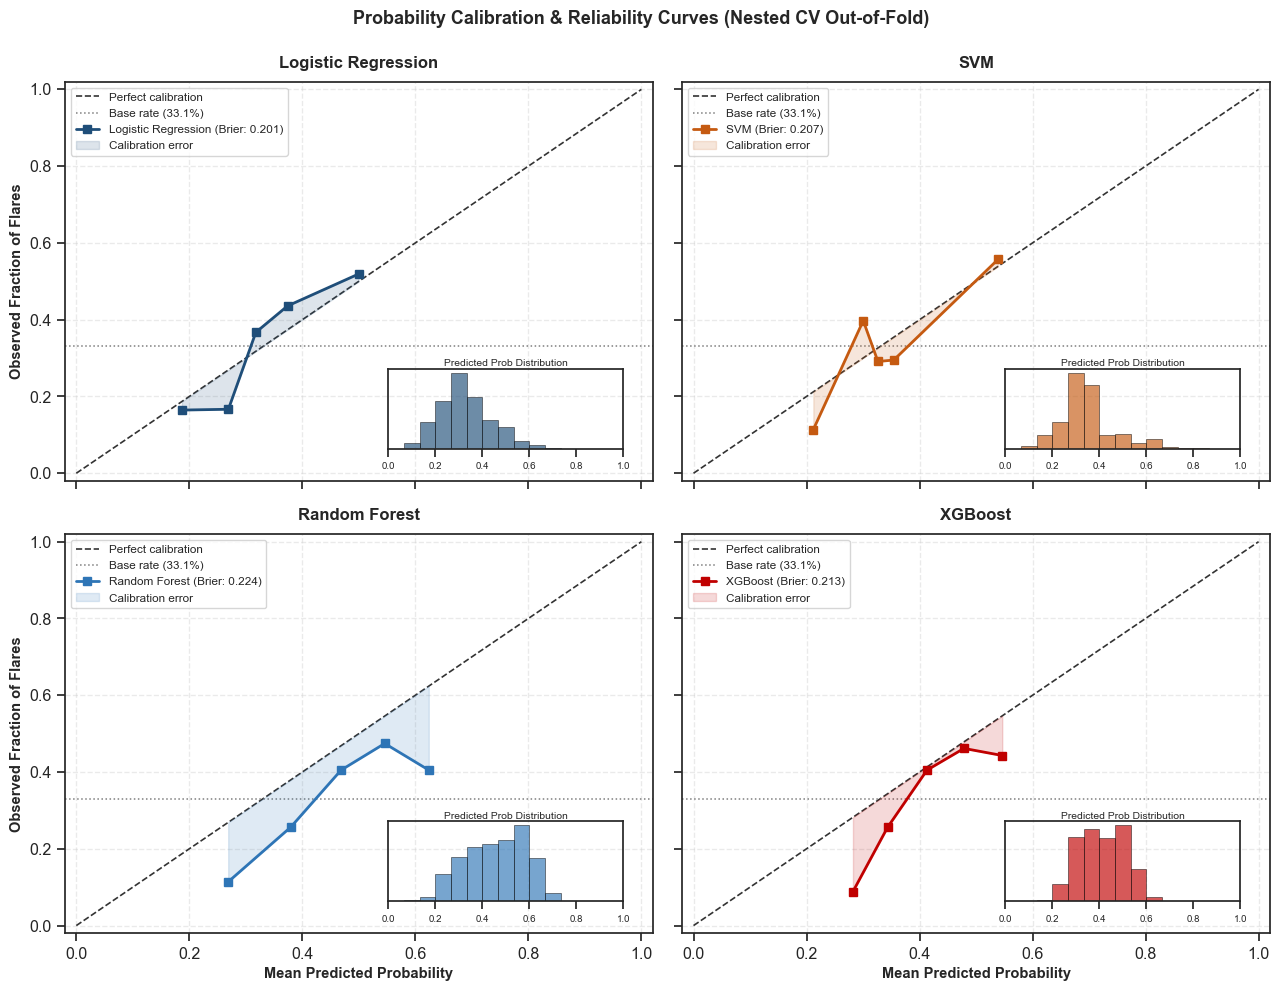

In [29]:
calibration_models = {
    'Logistic Regression': y_prob_lr,
    'SVM': y_prob_svm,
    'Random Forest': y_prob_rf,
    'XGBoost': y_prob_xgb,
}

y_true = np.asarray(y).ravel()
true_rate = y_true.mean()

colors = {
    'Logistic Regression': '#1f4e79',
    'SVM': '#c55a11',
    'Random Forest': '#2e75b6',
    'XGBoost': '#c00000',
}

# --- Plot Architecture ---
sns.set_theme(style='ticks', font_scale=1.05)
fig, axes = plt.subplots(2, 2, figsize=(13, 10), dpi=100, sharex=True, sharey=True)
axes = axes.flatten()

for idx, (model_name, y_prob) in enumerate(calibration_models.items()):
  ax = axes[idx]
  color = colors[model_name]

  # Compute calibration curve & Brier score
  fraction_of_pos, mean_pred = calibration_curve(
      y_true, y_prob, n_bins=5, strategy='quantile'
  )
  brier = brier_score_loss(y_true, y_prob)

  # 1. Reference lines
  ax.plot(
      [0, 1],
      [0, 1],
      linestyle='--',
      color='#333333',
      linewidth=1.2,
      label='Perfect calibration',
      zorder=1,
  )
  ax.axhline(
      true_rate,
      color='#7f7f7f',
      linestyle=':',
      linewidth=1.1,
      label=f'Base rate ({true_rate:.1%})',
      zorder=1,
  )

  # 2. Calibration curve & error fill
  ax.plot(
      mean_pred,
      fraction_of_pos,
      marker='s',
      markersize=6,
      linewidth=2,
      color=color,
      label=f'{model_name} (Brier: {brier:.3f})',
      zorder=3,
  )
  ax.fill_between(
      mean_pred,
      fraction_of_pos,
      mean_pred,
      alpha=0.15,
      color=color,
      label='Calibration error',
  )

  # 3. Mini probability distribution histogram at the bottom
  ax_hist = ax.inset_axes([0.55, 0.08, 0.40, 0.20])
  ax_hist.hist(y_prob, bins=15, range=(0, 1), color=color, alpha=0.65, edgecolor='black', linewidth=0.5)
  ax_hist.set_xlim(0, 1)
  ax_hist.set_yticks([])
  ax_hist.set_title('Predicted Prob Distribution', fontsize=7.5, pad=2)
  ax_hist.tick_params(axis='x', labelsize=7)
  ax_hist.patch.set_alpha(0.0)

  # 4. Panel aesthetics
  ax.set_xlim([-0.02, 1.02])
  ax.set_ylim([-0.02, 1.02])
  ax.set_title(f'{model_name}', fontsize=12, fontweight='bold', pad=10)
  ax.grid(True, linestyle='--', alpha=0.4)
  ax.legend(loc='upper left', fontsize=8.5, frameon=True, edgecolor='#cccccc')

  if idx in [2, 3]:
    ax.set_xlabel('Mean Predicted Probability', fontweight='bold', fontsize=10.5)
  if idx in [0, 2]:
    ax.set_ylabel('Observed Fraction of Flares', fontweight='bold', fontsize=10.5)

plt.suptitle(
    'Probability Calibration & Reliability Curves (Nested CV Out-of-Fold)',
    fontsize=13,
    fontweight='bold',
    y=0.99,
)
plt.tight_layout()
plt.show()

Learning curve

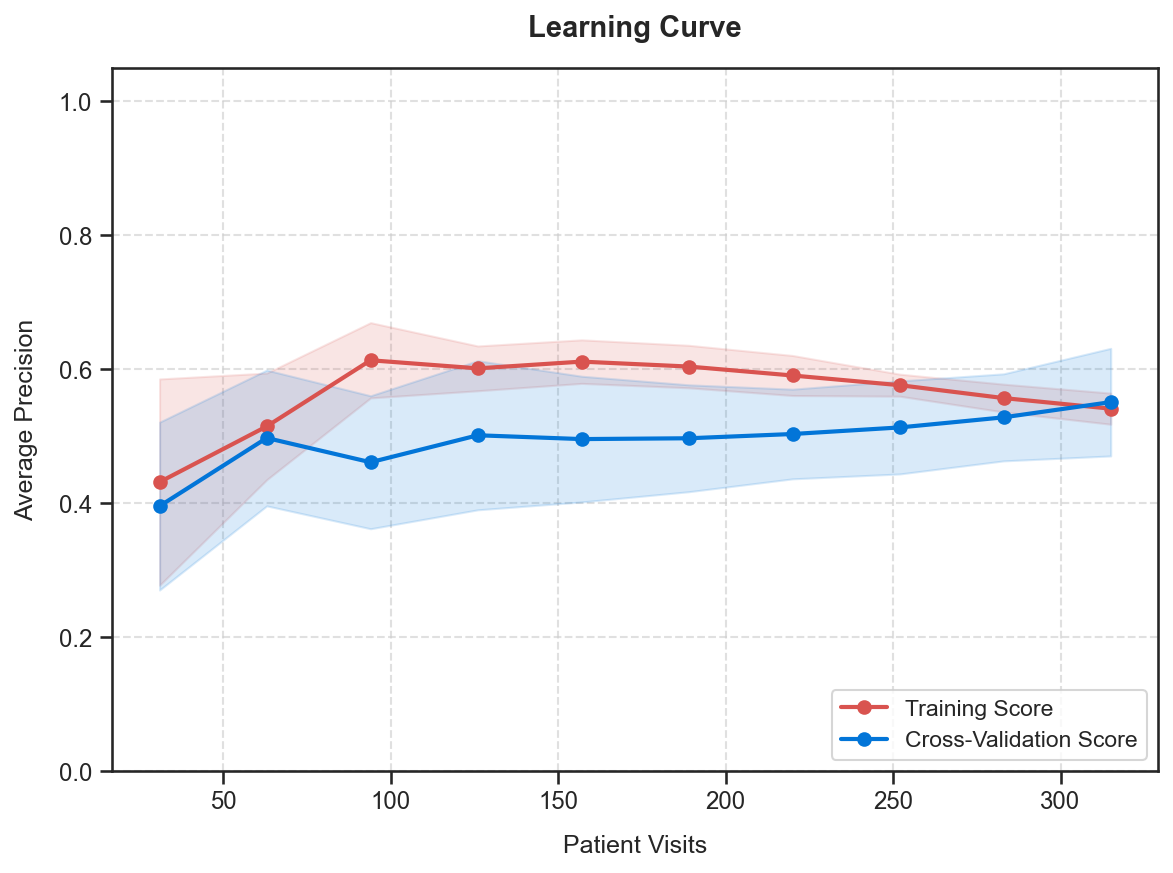

In [31]:
from sklearn.model_selection import learning_curve

champion_model = best_lr
train_sizes, train_scores, test_scores = learning_curve(
    estimator=champion_model,
    X=X,
    y=y,
    groups=groups,                
    cv=stratified_group_kfold, 
    scoring='average_precision',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 6), dpi=150)
plt.plot(train_sizes, train_mean, 'o-', color='#d9534f', label='Training Score', linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#d9534f')
plt.plot(train_sizes, test_mean, 'o-', color='#0275d8', label='Cross-Validation Score', linewidth=2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='#0275d8')


plt.title('Learning Curve', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Patient Visits', fontsize=12, labelpad=10)
plt.ylabel('Average Precision', fontsize=12, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.ylim(0.0, 1.05)
plt.tight_layout()
plt.show()

Confusion matrices

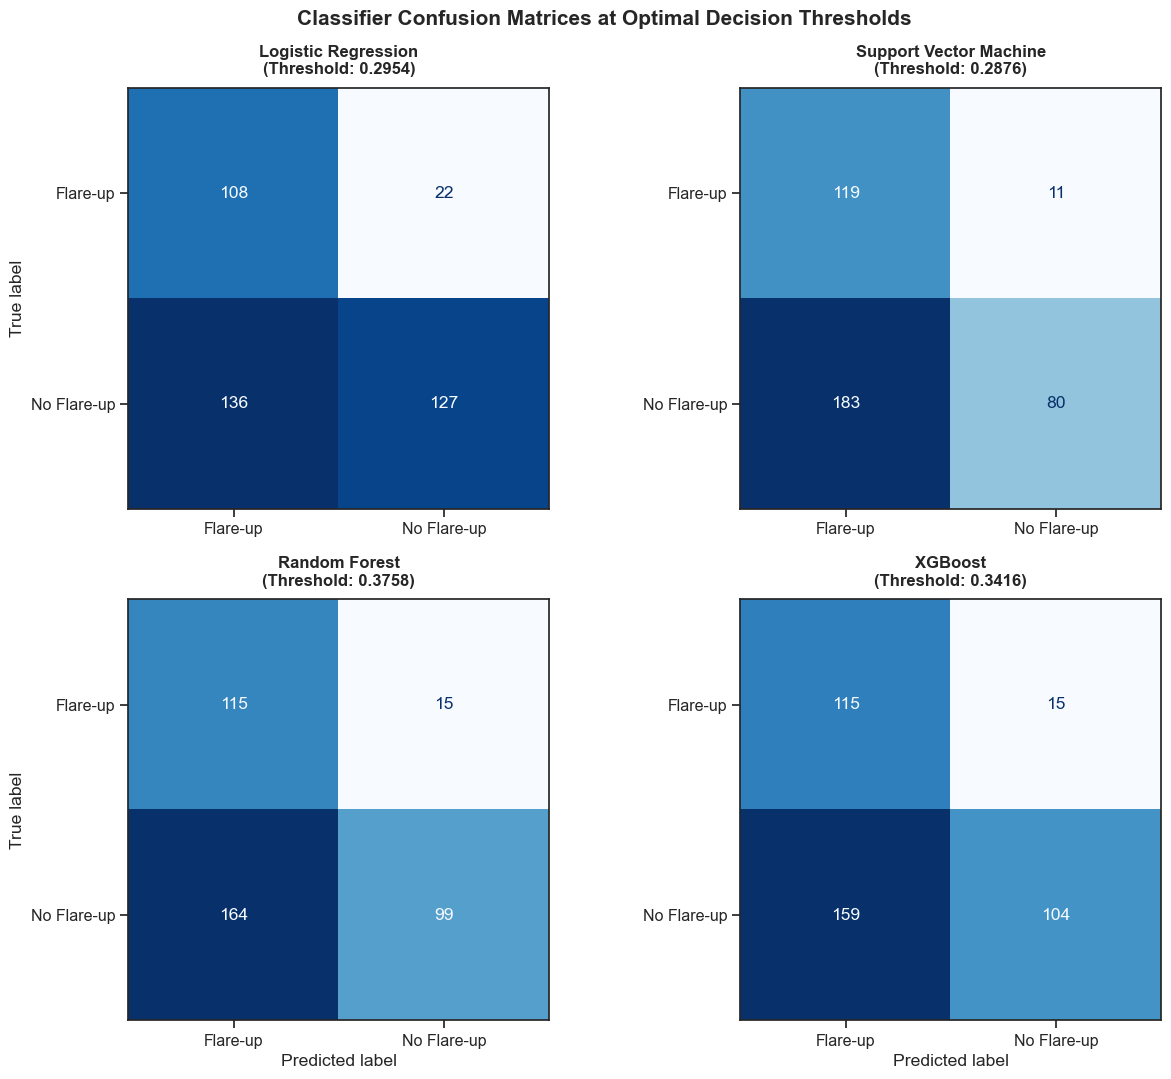

In [32]:
models_config = {
    'Logistic Regression':    {'key': 'Experiment_1_LR',      'threshold': 0.2954},
    'Support Vector Machine': {'key': 'Experiment_2_SVM',     'threshold': 0.2876}, 
    'Random Forest':          {'key': 'Experiment_3_RF',      'threshold': 0.3758},
    'XGBoost':                {'key': 'Experiment_4_XGB',     'threshold': 0.3416}
}

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten() 

for i, (model_name, config) in enumerate(models_config.items()):
    model_key = config['key']
    threshold = config['threshold']
    
    #Extract ground truth and predicted probabilities
    y_true = final_results[model_key]['y_true']
    y_prob = final_results[model_key]['y_prob']
    
    #Apply the specific optimal threshold for this classifier
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
    
    ax = axes[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Flare-up', 'No Flare-up'])
    disp.plot(cmap='Blues', ax=ax, colorbar=False) # Hiding individual side colorbars keeps the grid neat
    
    ax.grid(False)
    ax.set_title(f'{model_name}\n(Threshold: {threshold})', fontsize=12, fontweight='bold', pad=10)
    
    if i < 2:  
        ax.set_xlabel('')
    if i % 2 != 0: 
        ax.set_ylabel('')
        
plt.suptitle('Classifier Confusion Matrices at Optimal Decision Thresholds', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Final Conclusions

### Best Model
**Logistic Regression** achieved the strongest performance
across all primary metrics:

| Metric | Value |
|---|---|
| Average Precision | 0.508 |
| ROC-AUC | 0.695 |
| Recall (Flare) | 0.831 |
| Brier Score | 0.201 |
| Optimal Threshold | 0.295 |

### Why Logistic Regression Won
- Highest AP and ROC-AUC among all four classifiers
- Best probability calibration (Brier = 0.201 vs
  no-skill baseline of 0.221)
- Complete hyperparameter stability -> identical
  parameters selected across all five outer folds
- Produces a clinically interpretable five-variable
  prediction equation

### Prediction Equation
```
log-odds(flare) = 0.511 × DAS28_score + 0.053 × log_ESR + 0.032 × disease_duration² + 0.028 × log_CRP_normalised − 0.023 × age_at_visit -2.015
```

All five coefficient directions are consistent with established clinical knowledge. DAS28 score dominates at OR = 1.667 — a one standard deviation increase is
associated with a 67% increase in flare odds.

### Why Ensembles Did Not Win
Random Forest and XGBoost require substantially larger training sets to outperform regularised linear models when the predictive signal is predominantly linear.  
The learning curve confirms the model has not reached its performance ceiling.